In [7]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.distributions import Beta
import matplotlib.pyplot as plt

# Parameters
num_rounds = 10
valuation = 50
action_scale = 6  # Scale actions from [0,1] to [0,6]
num_iterations = 5000  # Number of training iterations
batch_size = 64        # Number of episodes per batch
learning_rate = 3e-4
gamma = 1.0            # Since rewards are at the end
epsilon = 0.2          # PPO clipping epsilon
num_epochs = 4         # PPO epochs
num_minibatches = 4    # Number of minibatches for PPO update

# Define the Auction Environment for Two Agents
class AuctionEnv:
    def __init__(self, num_rounds=10, valuation=50):
        self.num_rounds = num_rounds
        self.valuation = valuation
        self.action_scale = action_scale
        self.reset()

    def reset(self):
        self.t = self.num_rounds
        self.s = 0  # Indicator whether agent 1 currently has the highest bid
        self.current_bid_q1 = 0.0
        self.current_bid_q2 = 0.0
        self.done = False
        return self._get_obs()

    def _get_obs(self):
        # Observations for both agents: time remaining and whether they have the highest bid
        state_q1 = np.array([self.t / self.num_rounds, self.s], dtype=np.float32)
        state_q2 = np.array([self.t / self.num_rounds, 1 - self.s], dtype=np.float32)
        return state_q1, state_q2

    def step(self, action_q1, action_q2):
        # Actions are in [0,1], scale to [0,6]
        inc_bid_q1 = np.clip(action_q1[0], 0.0, 1.0) * self.action_scale
        inc_bid_q2 = np.clip(action_q2[0], 0.0, 1.0) * self.action_scale

        self.current_bid_q1 += inc_bid_q1
        self.current_bid_q2 += inc_bid_q2

        # Update who has the highest bid
        self.s = 1 if self.current_bid_q1 >= self.current_bid_q2 else 0

        self.t -= 1

        if self.t == 0:
            self.done = True
            # Compute rewards
            if self.current_bid_q1 > self.current_bid_q2 and self.current_bid_q1 <= self.valuation:
                reward_q1 = self.valuation - self.current_bid_q1
            else:
                reward_q1 = 0.0
            if self.current_bid_q2 > self.current_bid_q1 and self.current_bid_q2 <= self.valuation:
                reward_q2 = self.valuation - self.current_bid_q2
            else:
                reward_q2 = 0.0
        else:
            reward_q1 = 0.0
            reward_q2 = 0.0

        obs_q1, obs_q2 = self._get_obs()

        return (obs_q1, obs_q2), (reward_q1, reward_q2), self.done, {}

# Define the PPO Agent with Beta Distribution
class PPOAgent(nn.Module):
    def __init__(self, input_dim, learning_rate=3e-4):
        super(PPOAgent, self).__init__()
        # Policy network
        self.actor = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh()
        )
        self.alpha_head = nn.Linear(64, 1)
        self.beta_head = nn.Linear(64, 1)
        # Value network
        self.critic = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )
        self.optimizer = optim.Adam(self.parameters(), lr=learning_rate)

    def get_action(self, x):
        x = self.actor(x)
        alpha = F.softplus(self.alpha_head(x)) + 1.0  # Ensure alpha > 1
        beta = F.softplus(self.beta_head(x)) + 1.0    # Ensure beta > 1
        dist = Beta(alpha, beta)
        action = dist.sample()
        log_prob = dist.log_prob(action)
        return action, log_prob, dist

    def get_value(self, x):
        return self.critic(x)

    def update(self, batch_data, epsilon=0.2, num_epochs=4, num_minibatches=4):
        obs_batch, actions_batch, log_probs_old_batch, returns_batch, advantages_batch = batch_data
        batch_size = len(advantages_batch)
        for _ in range(num_epochs):
            indices = np.arange(batch_size)
            np.random.shuffle(indices)
            minibatch_size = batch_size // num_minibatches
            for start in range(0, batch_size, minibatch_size):
                end = start + minibatch_size
                mb_inds = indices[start:end]

                mb_obs = obs_batch[mb_inds]
                mb_actions = actions_batch[mb_inds]
                mb_log_probs_old = log_probs_old_batch[mb_inds]
                mb_advantages = advantages_batch[mb_inds]
                mb_returns = returns_batch[mb_inds]

                # Forward pass
                _, mb_log_probs, _ = self.get_action(mb_obs)
                values = self.get_value(mb_obs).squeeze()

                ratios = (mb_log_probs - mb_log_probs_old).exp().squeeze()

                # Policy loss
                surr1 = ratios * mb_advantages
                surr2 = torch.clamp(ratios, 1 - epsilon, 1 + epsilon) * mb_advantages
                policy_loss = -torch.min(surr1, surr2).mean()

                # Value loss
                value_loss = nn.MSELoss()(values, mb_returns)

                # Total loss
                loss = policy_loss + 0.5 * value_loss

                # Backpropagation
                self.optimizer.zero_grad()
                loss.backward()
                self.optimizer.step()

# Initialize Environment and Agents
env = AuctionEnv(num_rounds=num_rounds, valuation=valuation)
obs_dim = 2  # [time_remaining, has_highest_bid]
agent1 = PPOAgent(input_dim=obs_dim, learning_rate=learning_rate)
agent2 = PPOAgent(input_dim=obs_dim, learning_rate=learning_rate)

# Training Loop
for iteration in range(num_iterations):
    # Collect trajectories for both agents
    trajectories1 = []
    trajectories2 = []

    for episode in range(batch_size):
        # Reset environment and get initial observations
        obs1, obs2 = env.reset()
        # Lists to store episode data
        obs1_ep, actions1_ep, log_probs1_ep, values1_ep, rewards1_ep = [], [], [], [], []
        obs2_ep, actions2_ep, log_probs2_ep, values2_ep, rewards2_ep = [], [], [], [], []

        done = False
        while not done:
            obs1_tensor = torch.tensor(obs1, dtype=torch.float32).unsqueeze(0)
            obs2_tensor = torch.tensor(obs2, dtype=torch.float32).unsqueeze(0)

            # Agent 1 action
            action1, log_prob1, _ = agent1.get_action(obs1_tensor)
            value1 = agent1.get_value(obs1_tensor)

            # Agent 2 action
            action2, log_prob2, _ = agent2.get_action(obs2_tensor)
            value2 = agent2.get_value(obs2_tensor)

            # Step environment
            actions = (action1.detach().numpy(), action2.detach().numpy())
            (obs1_new, obs2_new), (reward1, reward2), done, _ = env.step(*actions)

            # Store experiences
            obs1_ep.append(obs1)
            actions1_ep.append(action1.detach().numpy()[0])
            log_probs1_ep.append(log_prob1.detach().numpy()[0])
            values1_ep.append(value1.detach().numpy()[0])
            rewards1_ep.append(reward1)

            obs2_ep.append(obs2)
            actions2_ep.append(action2.detach().numpy()[0])
            log_probs2_ep.append(log_prob2.detach().numpy()[0])
            values2_ep.append(value2.detach().numpy()[0])
            rewards2_ep.append(reward2)

            # Move to next state
            obs1, obs2 = obs1_new, obs2_new

        # Since rewards are only at the end, we assign the final reward to each time step
        total_reward1 = rewards1_ep[-1]
        total_reward2 = rewards2_ep[-1]
        rewards1_ep = [total_reward1] * len(rewards1_ep)
        rewards2_ep = [total_reward2] * len(rewards2_ep)

        # Compute returns and advantages for agent 1
        returns1 = []
        G = 0
        for r in reversed(rewards1_ep):
            G = r + gamma * G
            returns1.insert(0, G)
        returns1 = np.array(returns1, dtype=np.float32)
        values1_ep = np.array(values1_ep, dtype=np.float32)
        advantages1 = returns1 - values1_ep
        advantages1 = (advantages1 - advantages1.mean()) / (advantages1.std() + 1e-8)

        # Store trajectory for agent 1
        trajectory1 = (obs1_ep, actions1_ep, log_probs1_ep, returns1, advantages1)
        trajectories1.append(trajectory1)

        # Compute returns and advantages for agent 2
        returns2 = []
        G = 0
        for r in reversed(rewards2_ep):
            G = r + gamma * G
            returns2.insert(0, G)
        returns2 = np.array(returns2, dtype=np.float32)
        values2_ep = np.array(values2_ep, dtype=np.float32)
        advantages2 = returns2 - values2_ep
        advantages2 = (advantages2 - advantages2.mean()) / (advantages2.std() + 1e-8)

        # Store trajectory for agent 2
        trajectory2 = (obs2_ep, actions2_ep, log_probs2_ep, returns2, advantages2)
        trajectories2.append(trajectory2)

    # Prepare batch data for agent 1
    obs1_batch = np.concatenate([np.array(t[0], dtype=np.float32) for t in trajectories1], axis=0)
    actions1_batch = np.concatenate([np.array(t[1], dtype=np.float32) for t in trajectories1], axis=0)
    log_probs1_batch = np.concatenate([np.array(t[2], dtype=np.float32) for t in trajectories1], axis=0)
    returns1_batch = np.concatenate([np.array(t[3], dtype=np.float32) for t in trajectories1], axis=0)
    advantages1_batch = np.concatenate([np.array(t[4], dtype=np.float32) for t in trajectories1], axis=0)

    # Convert to tensors
    obs1_batch = torch.tensor(obs1_batch, dtype=torch.float32)
    actions1_batch = torch.tensor(actions1_batch, dtype=torch.float32).unsqueeze(1)
    log_probs1_batch = torch.tensor(log_probs1_batch, dtype=torch.float32).unsqueeze(1)
    returns1_batch = torch.tensor(returns1_batch, dtype=torch.float32)
    advantages1_batch = torch.tensor(advantages1_batch, dtype=torch.float32)

    # Update agent 1
    batch_data1 = (obs1_batch, actions1_batch, log_probs1_batch, returns1_batch, advantages1_batch)
    agent1.update(batch_data1, epsilon=epsilon, num_epochs=num_epochs, num_minibatches=num_minibatches)

    # Prepare batch data for agent 2
    obs2_batch = np.concatenate([np.array(t[0], dtype=np.float32) for t in trajectories2], axis=0)
    actions2_batch = np.concatenate([np.array(t[1], dtype=np.float32) for t in trajectories2], axis=0)
    log_probs2_batch = np.concatenate([np.array(t[2], dtype=np.float32) for t in trajectories2], axis=0)
    returns2_batch = np.concatenate([np.array(t[3], dtype=np.float32) for t in trajectories2], axis=0)
    advantages2_batch = np.concatenate([np.array(t[4], dtype=np.float32) for t in trajectories2], axis=0)

    # Convert to tensors
    obs2_batch = torch.tensor(obs2_batch, dtype=torch.float32)
    actions2_batch = torch.tensor(actions2_batch, dtype=torch.float32).unsqueeze(1)
    log_probs2_batch = torch.tensor(log_probs2_batch, dtype=torch.float32).unsqueeze(1)
    returns2_batch = torch.tensor(returns2_batch, dtype=torch.float32)
    advantages2_batch = torch.tensor(advantages2_batch, dtype=torch.float32)

    # Update agent 2
    batch_data2 = (obs2_batch, actions2_batch, log_probs2_batch, returns2_batch, advantages2_batch)
    agent2.update(batch_data2, epsilon=epsilon, num_epochs=num_epochs, num_minibatches=num_minibatches)

    # Optional: Print progress
    if (iteration + 1) % 100 == 0:
        avg_reward1 = np.mean([t[3][-1] for t in trajectories1])
        avg_reward2 = np.mean([t[3][-1] for t in trajectories2])
        print(f"Iteration {iteration + 1}/{num_iterations}, Avg Reward Agent 1: {avg_reward1:.2f}, Avg Reward Agent 2: {avg_reward2:.2f}")

# Play a Game and Visualize
def play_game(agent1, agent2):
    obs1, obs2 = env.reset()
    highest_bids_q1 = []
    highest_bids_q2 = []
    done = False
    while not done:
        obs1_tensor = torch.tensor(obs1, dtype=torch.float32).unsqueeze(0)
        obs2_tensor = torch.tensor(obs2, dtype=torch.float32).unsqueeze(0)

        with torch.no_grad():
            action1, _, _ = agent1.get_action(obs1_tensor)
            action2, _, _ = agent2.get_action(obs2_tensor)

        actions = (action1.numpy(), action2.numpy())
        (obs1_new, obs2_new), (reward1, reward2), done, _ = env.step(*actions)

        highest_bids_q1.append(env.current_bid_q1)
        highest_bids_q2.append(env.current_bid_q2)

        obs1, obs2 = obs1_new, obs2_new

    print(f"Final Reward Agent 1: {reward1}")
    print(f"Final Reward Agent 2: {reward2}")

    return highest_bids_q1, highest_bids_q2

highest_bids_q1, highest_bids_q2 = play_game(agent1, agent2)

def visualize_game(highest_bids_q1, highest_bids_q2):
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, num_rounds+1), highest_bids_q1, 'x-', label='Agent 1 Highest Bids', markersize=8)
    plt.plot(range(1, num_rounds+1), highest_bids_q2, 'o-', label='Agent 2 Highest Bids', markersize=5)
    plt.xlabel('Round')
    plt.ylabel('Cumulative Bid Amount')
    plt.title('Highest Bid Progression Over Rounds')
    plt.legend()
    plt.grid(True)
    plt.show()

visualize_game(highest_bids_q1, highest_bids_q2)


ValueError: all the input arrays must have same number of dimensions, but the array at index 0 has 2 dimension(s) and the array at index 1 has 1 dimension(s)

Iteration 100/500, Avg Reward Agent 1: 6.91, Avg Reward Agent 2: 8.64
Iteration 200/500, Avg Reward Agent 1: 7.59, Avg Reward Agent 2: 9.67
Iteration 300/500, Avg Reward Agent 1: 7.87, Avg Reward Agent 2: 8.35
Iteration 400/500, Avg Reward Agent 1: 7.95, Avg Reward Agent 2: 8.95
Iteration 500/500, Avg Reward Agent 1: 8.48, Avg Reward Agent 2: 7.49
Final Reward Agent 1: 0.0
Final Reward Agent 2: [13.996094]


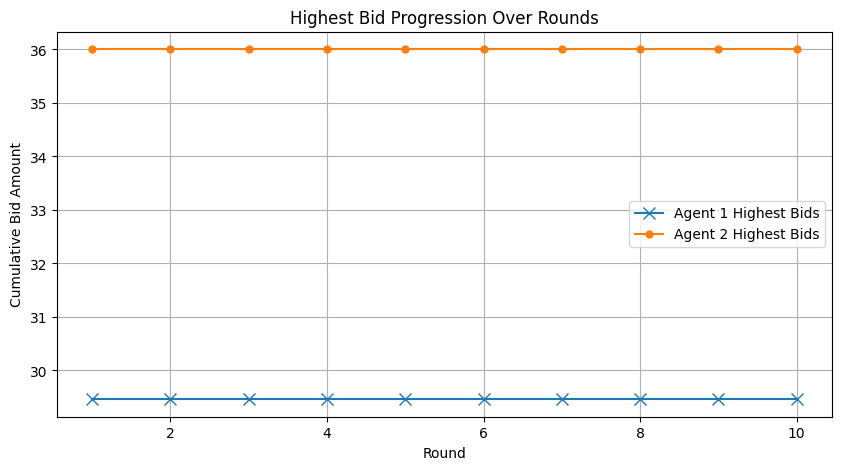

In [12]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.distributions import Beta
import matplotlib.pyplot as plt

# Parameters
num_rounds = 10        # The number of bidding rounds in the auction game.
valuation = 50         # The maximum value that agents place on winning the auction.
action_scale = 6       # Scale actions from [0,1] to [0,6], defining the range of possible bid increments.
num_iterations = 500  # The total number of training iterations (how many times the training loop runs).
batch_size = 32        # Number of episodes (games) played before performing a PPO update.
learning_rate = 3e-4   # The learning rate for updating the policy and value networks.
gamma = 1.0            # Discount factor for future rewards (1.0 means rewards are not discounted).
epsilon = 0.1          # PPO clipping epsilon, controlling how much the new policy is allowed to deviate from the old one.
num_epochs = 10        # The number of PPO epochs per training update (how many times the data is used to update the policy).
num_minibatches = 16    # Number of minibatches used for PPO update, splitting the batch into smaller chunks for training.


# Define the Auction Environment for Two Agents
class AuctionEnv:
    def __init__(self, num_rounds=10, valuation=50):
        self.num_rounds = num_rounds
        self.valuation = valuation
        self.action_scale = action_scale
        self.reset()

    def reset(self):
        self.t = self.num_rounds
        self.s = 0  # Indicator whether agent 1 currently has the highest bid
        self.current_bid_q1 = 0.0
        self.current_bid_q2 = 0.0
        self.done = False
        return self._get_obs()

    def _get_obs(self):
        # Observations for both agents: time remaining and whether they have the highest bid
        state_q1 = np.array([self.t / self.num_rounds, self.s], dtype=np.float32)
        state_q2 = np.array([self.t / self.num_rounds, 1 - self.s], dtype=np.float32)
        return state_q1, state_q2

    def step(self, action_q1, action_q2):
        # Actions are in [0,1], scale to [0,6]
        inc_bid_q1 = np.clip(action_q1[0], 0.0, 1.0) * self.action_scale
        inc_bid_q2 = np.clip(action_q2[0], 0.0, 1.0) * self.action_scale

        self.current_bid_q1 += inc_bid_q1
        self.current_bid_q2 += inc_bid_q2

        # Update who has the highest bid
        self.s = 1 if self.current_bid_q1 >= self.current_bid_q2 else 0

        self.t -= 1

        if self.t == 0:
            self.done = True
            # Compute rewards
            if self.current_bid_q1 > self.current_bid_q2 and self.current_bid_q1 <= self.valuation:
                reward_q1 = self.valuation - self.current_bid_q1
            else:
                reward_q1 = 0.0
            if self.current_bid_q2 > self.current_bid_q1 and self.current_bid_q2 <= self.valuation:
                reward_q2 = self.valuation - self.current_bid_q2
            else:
                reward_q2 = 0.0
        else:
            reward_q1 = 0.0
            reward_q2 = 0.0

        obs_q1, obs_q2 = self._get_obs()

        return (obs_q1, obs_q2), (reward_q1, reward_q2), self.done, {}

# Define the PPO Agent with Beta Distribution
class PPOAgent(nn.Module):
    def __init__(self, input_dim, learning_rate=3e-4):
        super(PPOAgent, self).__init__()
        # Policy network
        self.actor = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh()
        )
        self.alpha_head = nn.Linear(64, 1)
        self.beta_head = nn.Linear(64, 1)
        # Value network
        self.critic = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )
        self.optimizer = optim.Adam(self.parameters(), lr=learning_rate)

    def get_action(self, x):
        x = self.actor(x)
        alpha = F.softplus(self.alpha_head(x)) + 1.0  # Ensure alpha > 1
        beta = F.softplus(self.beta_head(x)) + 1.0    # Ensure beta > 1
        dist = Beta(alpha, beta)
        action = dist.sample()
        log_prob = dist.log_prob(action)
        return action, log_prob, dist

    def get_value(self, x):
        return self.critic(x)

    def update(self, batch_data, epsilon=0.2, num_epochs=4, num_minibatches=4):
        obs_batch, actions_batch, log_probs_old_batch, returns_batch, advantages_batch = batch_data
        batch_size = len(advantages_batch)
        for _ in range(num_epochs):
            indices = np.arange(batch_size)
            np.random.shuffle(indices)
            minibatch_size = batch_size // num_minibatches
            for start in range(0, batch_size, minibatch_size):
                end = start + minibatch_size
                mb_inds = indices[start:end]

                mb_obs = obs_batch[mb_inds]
                mb_actions = actions_batch[mb_inds]
                mb_log_probs_old = log_probs_old_batch[mb_inds]
                mb_advantages = advantages_batch[mb_inds]
                mb_returns = returns_batch[mb_inds]

                # Forward pass
                action_new, mb_log_probs, _ = self.get_action(mb_obs)
                values = self.get_value(mb_obs).squeeze()

                ratios = (mb_log_probs - mb_log_probs_old).exp().squeeze()

                # Policy loss
                surr1 = ratios * mb_advantages
                surr2 = torch.clamp(ratios, 1 - epsilon, 1 + epsilon) * mb_advantages
                policy_loss = -torch.min(surr1, surr2).mean()

                # Value loss
                value_loss = nn.MSELoss()(values, mb_returns)

                # Total loss
                loss = policy_loss + 0.5 * value_loss

                # Backpropagation
                self.optimizer.zero_grad()
                loss.backward()
                self.optimizer.step()

# Initialize Environment and Agents
env = AuctionEnv(num_rounds=num_rounds, valuation=valuation)
obs_dim = 2  # [time_remaining, has_highest_bid]
agent1 = PPOAgent(input_dim=obs_dim, learning_rate=learning_rate)
agent2 = PPOAgent(input_dim=obs_dim, learning_rate=learning_rate)

# Training Loop
for iteration in range(num_iterations):
    # Collect trajectories for both agents
    trajectories1 = []
    trajectories2 = []

    for episode in range(batch_size):
        # Reset environment and get initial observations
        obs1, obs2 = env.reset()
        # Lists to store episode data
        obs1_ep, actions1_ep, log_probs1_ep, values1_ep, rewards1_ep = [], [], [], [], []
        obs2_ep, actions2_ep, log_probs2_ep, values2_ep, rewards2_ep = [], [], [], [], []

        done = False
        while not done:
            obs1_tensor = torch.tensor(obs1, dtype=torch.float32).unsqueeze(0)
            obs2_tensor = torch.tensor(obs2, dtype=torch.float32).unsqueeze(0)

            # Agent 1 action
            action1, log_prob1, _ = agent1.get_action(obs1_tensor)
            value1 = agent1.get_value(obs1_tensor)

            # Agent 2 action
            action2, log_prob2, _ = agent2.get_action(obs2_tensor)
            value2 = agent2.get_value(obs2_tensor)

            # Step environment
            actions = (action1.detach().numpy(), action2.detach().numpy())
            (obs1_new, obs2_new), (reward1, reward2), done, _ = env.step(*actions)

            # Store experiences
            obs1_ep.append(obs1)
            actions1_ep.append(action1.detach().numpy()[0])
            log_probs1_ep.append(log_prob1.detach().numpy()[0])
            values1_ep.append(value1.detach().numpy()[0])
            rewards1_ep.append(reward1)

            obs2_ep.append(obs2)
            actions2_ep.append(action2.detach().numpy()[0])
            log_probs2_ep.append(log_prob2.detach().numpy()[0])
            values2_ep.append(value2.detach().numpy()[0])
            rewards2_ep.append(reward2)

            # Move to next state
            obs1, obs2 = obs1_new, obs2_new

        # Since rewards are only at the end, assign the final reward to each time step
        total_reward1 = rewards1_ep[-1]
        total_reward2 = rewards2_ep[-1]
        rewards1_ep = [total_reward1] * len(rewards1_ep)
        rewards2_ep = [total_reward2] * len(rewards2_ep)

        # Compute returns and advantages for agent 1
        returns1 = []
        G = 0
        for r in reversed(rewards1_ep):
            G = r + gamma * G
            returns1.insert(0, G)
        returns1 = np.array(returns1, dtype=np.float32).reshape(-1)
        values1_ep = np.array(values1_ep, dtype=np.float32).reshape(-1)
        advantages1 = returns1 - values1_ep
        advantages1 = (advantages1 - advantages1.mean()) / (advantages1.std() + 1e-8)
        advantages1 = advantages1.reshape(-1)

        # Store trajectory for agent 1
        trajectory1 = (obs1_ep, actions1_ep, log_probs1_ep, returns1, advantages1)
        trajectories1.append(trajectory1)

        # Compute returns and advantages for agent 2
        returns2 = []
        G = 0
        for r in reversed(rewards2_ep):
            G = r + gamma * G
            returns2.insert(0, G)
        returns2 = np.array(returns2, dtype=np.float32).reshape(-1)
        values2_ep = np.array(values2_ep, dtype=np.float32).reshape(-1)
        advantages2 = returns2 - values2_ep
        advantages2 = (advantages2 - advantages2.mean()) / (advantages2.std() + 1e-8)
        advantages2 = advantages2.reshape(-1)

        # Store trajectory for agent 2
        trajectory2 = (obs2_ep, actions2_ep, log_probs2_ep, returns2, advantages2)
        trajectories2.append(trajectory2)

    # Prepare batch data for agent 1
    obs1_batch = np.concatenate([np.array(t[0], dtype=np.float32) for t in trajectories1], axis=0)
    #print(f"obs1_batch shape: {obs1_batch.shape}")
    actions1_batch = np.concatenate([np.array(t[1], dtype=np.float32).reshape(-1, 1) for t in trajectories1], axis=0)
    #print(f"actions1_batch shape: {actions1_batch.shape}")
    log_probs1_batch = np.concatenate([np.array(t[2], dtype=np.float32).reshape(-1, 1) for t in trajectories1], axis=0)
    #print(f"log_probs1_batch shape: {log_probs1_batch.shape}")
    returns1_batch = np.concatenate([np.array(t[3], dtype=np.float32).reshape(-1) for t in trajectories1], axis=0)
    #print(f"returns1_batch shape: {returns1_batch.shape}")
    advantages1_batch = np.concatenate([np.array(t[4], dtype=np.float32).reshape(-1) for t in trajectories1], axis=0)
    #print(f"advantages1_batch shape: {advantages1_batch.shape}")

    # Convert to tensors
    obs1_batch = torch.tensor(obs1_batch, dtype=torch.float32)
    actions1_batch = torch.tensor(actions1_batch, dtype=torch.float32)
    log_probs1_batch = torch.tensor(log_probs1_batch, dtype=torch.float32)
    returns1_batch = torch.tensor(returns1_batch, dtype=torch.float32)
    advantages1_batch = torch.tensor(advantages1_batch, dtype=torch.float32)

    # Update agent 1
    batch_data1 = (obs1_batch, actions1_batch, log_probs1_batch, returns1_batch, advantages1_batch)
    agent1.update(batch_data1, epsilon=epsilon, num_epochs=num_epochs, num_minibatches=num_minibatches)

    # Prepare batch data for agent 2
    obs2_batch = np.concatenate([np.array(t[0], dtype=np.float32) for t in trajectories2], axis=0)
    #print(f"obs2_batch shape: {obs2_batch.shape}")
    actions2_batch = np.concatenate([np.array(t[1], dtype=np.float32).reshape(-1, 1) for t in trajectories2], axis=0)
    #print(f"actions2_batch shape: {actions2_batch.shape}")
    log_probs2_batch = np.concatenate([np.array(t[2], dtype=np.float32).reshape(-1, 1) for t in trajectories2], axis=0)
    #print(f"log_probs2_batch shape: {log_probs2_batch.shape}")
    returns2_batch = np.concatenate([np.array(t[3], dtype=np.float32).reshape(-1) for t in trajectories2], axis=0)
    #print(f"returns2_batch shape: {returns2_batch.shape}")
    advantages2_batch = np.concatenate([np.array(t[4], dtype=np.float32).reshape(-1) for t in trajectories2], axis=0)
    #print(f"advantages2_batch shape: {advantages2_batch.shape}")

    # Convert to tensors
    obs2_batch = torch.tensor(obs2_batch, dtype=torch.float32)
    actions2_batch = torch.tensor(actions2_batch, dtype=torch.float32)
    log_probs2_batch = torch.tensor(log_probs2_batch, dtype=torch.float32)
    returns2_batch = torch.tensor(returns2_batch, dtype=torch.float32)
    advantages2_batch = torch.tensor(advantages2_batch, dtype=torch.float32)

    # Update agent 2
    batch_data2 = (obs2_batch, actions2_batch, log_probs2_batch, returns2_batch, advantages2_batch)
    agent2.update(batch_data2, epsilon=epsilon, num_epochs=num_epochs, num_minibatches=num_minibatches)

    # Optional: Print progress
    if (iteration + 1) % 100 == 0:
        avg_reward1 = np.mean([t[3][-1] for t in trajectories1])
        avg_reward2 = np.mean([t[3][-1] for t in trajectories2])
        print(f"Iteration {iteration + 1}/{num_iterations}, Avg Reward Agent 1: {avg_reward1:.2f}, Avg Reward Agent 2: {avg_reward2:.2f}")

# Play a Game and Visualize
def play_game(agent1, agent2):
    obs1, obs2 = env.reset()
    highest_bids_q1 = []
    highest_bids_q2 = []
    done = False
    while not done:
        obs1_tensor = torch.tensor(obs1, dtype=torch.float32).unsqueeze(0)
        obs2_tensor = torch.tensor(obs2, dtype=torch.float32).unsqueeze(0)

        with torch.no_grad():
            action1, _, _ = agent1.get_action(obs1_tensor)
            action2, _, _ = agent2.get_action(obs2_tensor)

        actions = (action1.numpy(), action2.numpy())
        (obs1_new, obs2_new), (reward1, reward2), done, _ = env.step(*actions)

        highest_bids_q1.append(env.current_bid_q1)
        highest_bids_q2.append(env.current_bid_q2)

        obs1, obs2 = obs1_new, obs2_new

    print(f"Final Reward Agent 1: {reward1}")
    print(f"Final Reward Agent 2: {reward2}")

    return highest_bids_q1, highest_bids_q2

highest_bids_q1, highest_bids_q2 = play_game(agent1, agent2)

def visualize_game(highest_bids_q1, highest_bids_q2):
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, num_rounds+1), highest_bids_q1, 'x-', label='Agent 1 Highest Bids', markersize=8)
    plt.plot(range(1, num_rounds+1), highest_bids_q2, 'o-', label='Agent 2 Highest Bids', markersize=5)
    plt.xlabel('Round')
    plt.ylabel('Cumulative Bid Amount')
    plt.title('Highest Bid Progression Over Rounds')
    plt.legend()
    plt.grid(True)
    plt.show()

visualize_game(highest_bids_q1, highest_bids_q2)

Final Reward Agent 1: [10.785904]
Final Reward Agent 2: 0.0


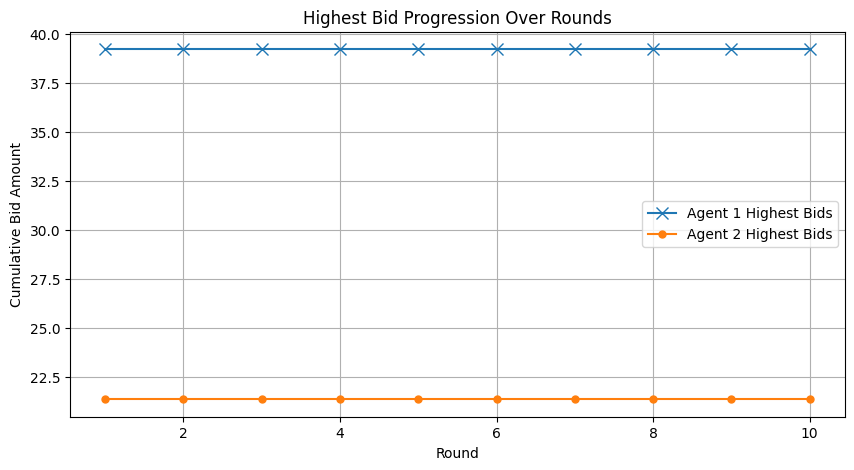

In [15]:

highest_bids_q1, highest_bids_q2 = play_game(agent1, agent2)

def visualize_game(highest_bids_q1, highest_bids_q2):
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, num_rounds+1), highest_bids_q1, 'x-', label='Agent 1 Highest Bids', markersize=8)
    plt.plot(range(1, num_rounds+1), highest_bids_q2, 'o-', label='Agent 2 Highest Bids', markersize=5)
    plt.xlabel('Round')
    plt.ylabel('Cumulative Bid Amount')
    plt.title('Highest Bid Progression Over Rounds')
    plt.legend()
    plt.grid(True)
    plt.show()

visualize_game(highest_bids_q1, highest_bids_q2)